In [32]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import seaborn as sns

In [2]:
from training.train_decoder import download_model_and_config, load_model
import einops

training decoder


In [3]:
from torch.utils.data import DataLoader
from generators.subseries_converter import EchoStateDataset
from models.vanila_decoder_transformer import TransformerDecoderModel

model_path, config = download_model_and_config('s2gk8uag')
model = load_model(model_path, config)
model.to('cuda')
model_benchmark = TransformerDecoderModel(config=config)
model_benchmark.to('cuda')
model_benchmark.eval()
config['dataset']['train']['num_series'] = 10_000
# config['dataset']['train']['series_length'] = 200
dataset_config = config.get('dataset', {})
train_dataset = EchoStateDataset(config=config, training=True, chamber_label=True)
val_dataset = EchoStateDataset(config=config, training=False, chamber_label=True)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False
)
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb:   1 of 1 files downloaded.  
/home/wojciech/private/magisterka/TFTS/training/train_decoder.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file

In [14]:
class Probe(nn.Module):
    def __init__(self, model, layer_name, hidden_features, out_features):
        super(Probe, self).__init__()
        self.model = model
        self.layer_name = layer_name
        self.hook = None
        self.probe = None
        self.hidden_features = hidden_features
        self.out_features = out_features

        # Find the layer and register a hook
        for name, layer in self.model.named_modules():
            if name == self.layer_name:
                self.hook = layer.register_forward_hook(self._hook_fn)
                self.probe = nn.Sequential(
                    nn.Linear(layer.out_features, self.out_features),
                    # nn.ReLU(),
                    # nn.Linear(self.hidden_features, self.out_features)
                    )
                break
        if self.hook is None:
            raise ValueError(f"Layer {self.layer_name} not found in the model.")

    def _hook_fn(self, module, input, output):
        self.activation = output

    def forward(self, x):
        _ = self.model(x[:, :-1, :])
        if hasattr(self, 'activation'):
            return self.probe(self.activation)
        else:
            raise RuntimeError("Activation not captured. Ensure the forward pass is executed.")

In [15]:
class ProbeOptim:
    def __init__(self, underlying_model, current):
        self.probe = Probe(underlying_model, 'transformer_decoder.layers.3.linear2', hidden_features=200, out_features=100)
        self.probe.to('cuda')
        self.optimizer = torch.optim.Adam(self.probe.probe.parameters(), lr=0.01)
        self.current = current
        self.numerator = torch.zeros(100).to('cuda')
        self.denominator = torch.zeros(100).to('cuda')

    def step(self, x, y):
        output = self.probe(x)
        output = einops.rearrange(output, 'batch token neuron -> batch neuron token')
        if self.current:
            target = y[:, :, 1:]  # Current layer
        else:
            target = y[:, :, :-1]  # Previous layer
        loss = nn.functional.mse_loss(output, target)
        loss.backward()
        self.optimizer.step()
        self.optimizer.zero_grad()

    def eval(self, x, y):
        with torch.no_grad():
            output = self.probe(x)
            output = einops.rearrange(output, 'batch token neuron -> batch neuron token')
            if self.current:
                target = y[:, :, 1:]  # Current layer
            else:
                target = y[:, :, :-1]  # Previous layer
            numerator = torch.sum(torch.sum((target - output) ** 2, dim=2), dim=0)
            denominator = torch.sum(torch.sum((target - target.mean()) ** 2, dim=2), dim=0)
            r2 = 1 - (numerator / denominator)
        return torch.quantile(r2, torch.tensor([0.1, 0.5, 0.9]).to('cuda'))  # Return quantiles of R^2

    def full_eval(self, x, y):
        with torch.no_grad():
            output = self.probe(x)
            output = einops.rearrange(output, 'batch token neuron -> batch neuron token')
            if self.current:
                target = y[:, :, 1:]  # Current layer
            else:
                target = y[:, :, :-1]  # Previous layer
            numerator = torch.sum(torch.sum((target - output) ** 2, dim=2), dim=0)
            denominator = torch.sum(torch.sum((target - target.mean()) ** 2, dim=2), dim=0)
            self.numerator += numerator
            self.denominator += denominator

    def get_full_eval_result(self):
        if self.denominator.sum() == 0:
            return None
        return 1 - (self.numerator / self.denominator)

In [17]:
import numpy as np
from tqdm import tqdm
probes_linear = {'previous_benchmark': ProbeOptim(model_benchmark, False),
          'current_benchmark': ProbeOptim(model_benchmark, True),
          'previous_probe': ProbeOptim(model, False),
          'current_probe': ProbeOptim(model, True)}
for epoch in range(1):
    loss = np.array([0.0])
    i = 0
    for x, y in tqdm(train_loader, total=len(train_loader)):
        x = x.to('cuda')
        y = y.to('cuda')
        if i % 10 == 0:
            for name, probe in probes_linear.items():
                print(f'{name}, {probe.eval(x, y)}')
        for probe in probes_linear.values():
            probe.step(x, y)
        i += 1

  0%|          | 0/157 [00:00<?, ?it/s]

previous_benchmark, tensor([-14.5666,  -2.2097,  -0.0752], device='cuda:0')
current_benchmark, tensor([-12.2194,  -2.1141,  -0.1548], device='cuda:0')
previous_probe, tensor([-3.2305, -0.7373, -0.0975], device='cuda:0')
current_probe, tensor([-5.0002, -0.7106, -0.1497], device='cuda:0')


  6%|▋         | 10/157 [00:12<03:02,  1.24s/it]

previous_benchmark, tensor([-3.7340, -0.5017,  0.1393], device='cuda:0')
current_benchmark, tensor([-3.5756, -0.6211, -0.0976], device='cuda:0')
previous_probe, tensor([-0.1735,  0.1535,  0.4965], device='cuda:0')
current_probe, tensor([-0.5361, -0.0055,  0.0890], device='cuda:0')


 13%|█▎        | 20/157 [00:24<02:42,  1.19s/it]

...

 94%|█████████▎| 147/157 [03:00<00:13,  1.34s/it]

-----------------------------------------------
Initial seed: 21000
Number of series: 10000
-----------------------------------------------


 96%|█████████▌| 151/157 [03:05<00:07,  1.29s/it]

previous_benchmark, tensor([0.0417, 0.1932, 0.7466], device='cuda:0')
current_benchmark, tensor([0.0074, 0.0619, 0.2291], device='cuda:0')
previous_probe, tensor([0.2147, 0.3361, 0.7550], device='cuda:0')
current_probe, tensor([0.0407, 0.1164, 0.2992], device='cuda:0')


100%|██████████| 157/157 [03:13<00:00,  1.23s/it]


In [42]:
numerator_cumsum = 0.0
denominator_cumsum = 0.0

with torch.no_grad():
    for x, y in tqdm(val_loader, total=len(val_loader)):
        x = x.to('cuda')
        y = y.to('cuda')
        for probe in probes_linear.values():
            probe.full_eval(x, y)

100%|██████████| 63/63 [00:19<00:00,  3.28it/s]


In [43]:
for name, probe in probes_linear.items():
    res = f'{name} R^2: '
    for q in [0.1, 0.25, 0.5, 0.75, 0.9]:
        res += f'q{q}: {torch.quantile(probe.get_full_eval_result(), q).item():.4f}, '
    print(res[: -2])  # Remove the last comma and space

previous_benchmark R^2: q0.1: 0.0274, q0.25: 0.0778, q0.5: 0.1774, q0.75: 0.4693, q0.9: 0.7476
current_benchmark R^2: q0.1: 0.0043, q0.25: 0.0172, q0.5: 0.0580, q0.75: 0.1130, q0.9: 0.2233
previous_probe R^2: q0.1: 0.2156, q0.25: 0.2499, q0.5: 0.3268, q0.75: 0.5447, q0.9: 0.7493
current_probe R^2: q0.1: 0.0443, q0.25: 0.0727, q0.5: 0.1178, q0.75: 0.1977, q0.9: 0.3126


In [55]:
#improvement calculation
probe_types = ['previous', 'current']
res = {}
for probe_type in probe_types:
    probe_model = probes[f'{probe_type}_probe']
    probe_benchmark = probes[f'{probe_type}_benchmark']
    r2 =(probe_model.get_full_eval_result() - probe_benchmark.get_full_eval_result()).detach().cpu().numpy()
    res[probe_type] = r2


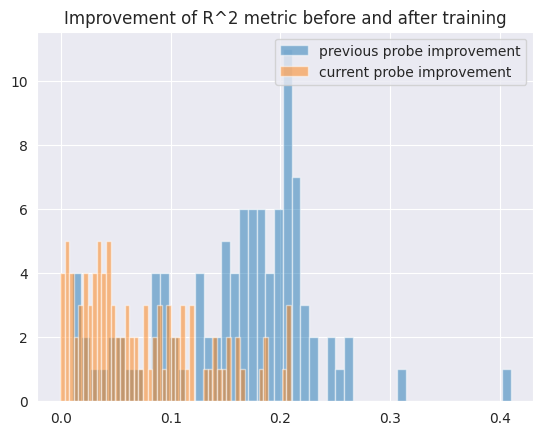

In [56]:
plt.title('Improvement of R^2 metric before and after training')
for probe_type in probe_types:
    plt.hist(res[probe_type], bins=50, alpha=0.5, label=f'{probe_type} probe improvement')
plt.legend()

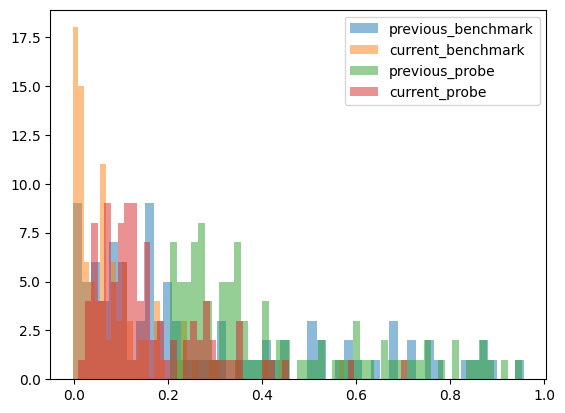

In [48]:
for type, probe in probes.items():
    plt.hist(probe.get_full_eval_result().detach().cpu().numpy(), bins=50, alpha=0.5, label=type)
plt.legend()

Text(0.5, 1.0, 'Benchmark model')

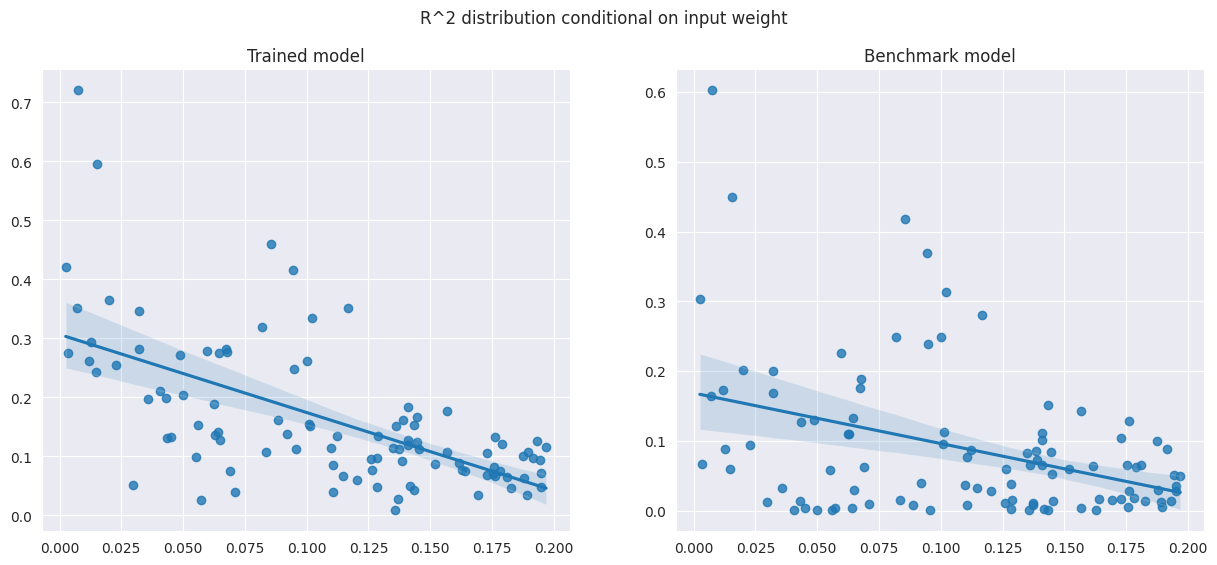

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.suptitle("R^2 distribution conditional on input weight")
sns.regplot(
    x=np.abs(val_loader.dataset.esn.W_in.detach().cpu().numpy()),
    y=(probes['current_probe'].get_full_eval_result()).detach().cpu().numpy(),
    ax=ax1
)
ax1.set_title("Trained model")
sns.regplot(
    x=np.abs(val_loader.dataset.esn.W_in.detach().cpu().numpy()),
    y=(probes['current_benchmark'].get_full_eval_result()).detach().cpu().numpy(),
    ax=ax2
)
ax2.set_title("Benchmark model")

<Axes: >

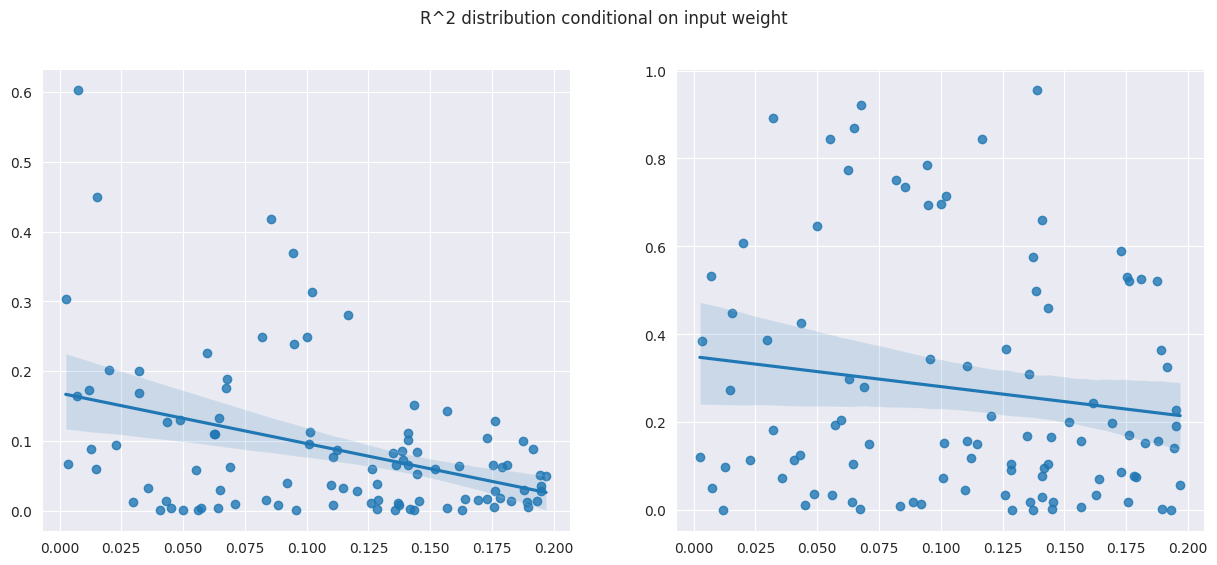

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.suptitle("R^2 distribution conditional on input weight")
sns.regplot(
    x=np.abs(val_loader.dataset.esn.W_in.detach().cpu().numpy()),
    y=(probes['current_benchmark'].get_full_eval_result()).detach().cpu().numpy(),
    ax=ax1
)
sns.regplot(
    x=np.abs(val_loader.dataset.esn.W_in.detach().cpu().numpy()),
    y=(probes['previous_benchmark'].get_full_eval_result()).detach().cpu().numpy(),
    ax=ax2
)

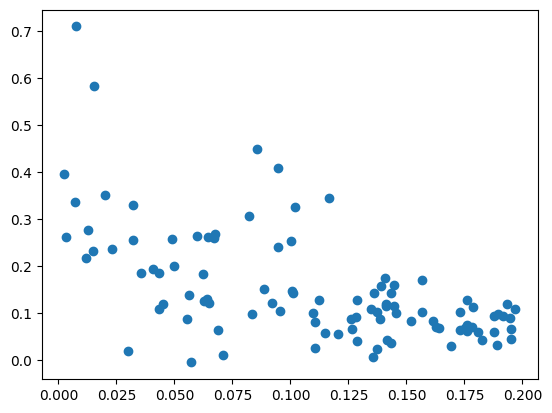

In [15]:
plt.scatter(
    np.abs(val_loader.dataset.esn.W_in.detach().cpu().numpy()), neuronwise_r2.detach().cpu().numpy())

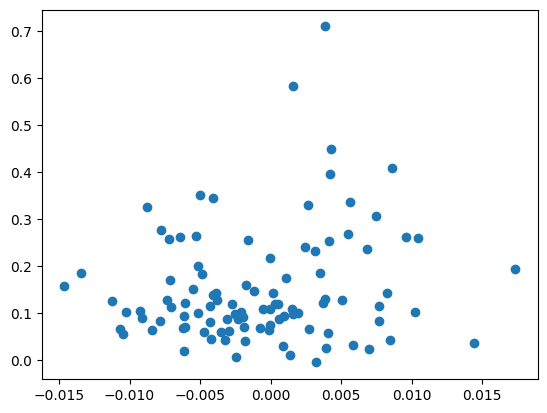

In [17]:
plt.scatter(np.mean(val_loader.dataset.esn.W.detach().cpu().numpy(), axis=1), neuronwise_r2.detach().cpu().numpy())